# Predicting Supply Chain Disruptions
## Machine Learning II — MBDS 2026 Group Assignment

**Team:** Jan · Caspar · Lea · Ghezlan · Fouad  
**Dataset:** Global Supply Chain Risk 2026 (`global_supply_chain_risk_2026.csv`)  
**Objective:** Build a binary classification model to predict whether a shipment will experience a disruption (`Disruption_Occurred`).

---
### Notebook Structure
1. Problem Statement & Data Loading
2. Exploratory Data Analysis (EDA)
3. Feature Engineering & Preprocessing
4. Model Training & Cross-Validation
5. Model Evaluation & Comparison
6. Hyperparameter Tuning
7. Model Interpretability & Validation
8. Conclusions

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import scipy

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    RandomizedSearchCV, GridSearchCV, learning_curve
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, f1_score, precision_score, recall_score,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
import shap

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

RANDOM_STATE = 42
print('Libraries loaded successfully.')
print(f'  pandas       {pd.__version__}')
print(f'  numpy        {np.__version__}')
print(f'  matplotlib   {plt.matplotlib.__version__}')
print(f'  seaborn      {sns.__version__}')
print(f'  scipy        {scipy.__version__}')
import sklearn; print(f'  scikit-learn {sklearn.__version__}')
import imblearn; print(f'  imbalanced-learn {imblearn.__version__}')
print(f'  shap         {shap.__version__}')


c:\Users\leasa\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Libraries loaded successfully.
  pandas       3.0.1
  numpy        2.1.3
  matplotlib   3.10.8
  seaborn      0.13.2
  scipy        1.17.1
  scikit-learn 1.8.0
  imbalanced-learn 0.14.1
  shap         0.51.0


---
## 1. Problem Statement & Data Loading

In [2]:
df = pd.read_csv('3_Database/global_supply_chain_risk_2026.csv')
print(f'Shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
df.head()

Shape: (5000, 14)
Missing values: 0


,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


In [3]:
print(df.dtypes)
print('\n--- Descriptive Statistics ---')
df.describe()

Shipment_ID                      str
Date                             str
Origin_Port                      str
Destination_Port                 str
Transport_Mode                   str
Product_Category                 str
Distance_km                  float64
Weight_MT                    float64
Fuel_Price_Index             float64
Geopolitical_Risk_Score      float64
Weather_Condition                str
Carrier_Reliability_Score    float64
Lead_Time_Days               float64
Disruption_Occurred            int64
dtype: object

--- Descriptive Statistics ---


,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,7704.063888,246.252052,2.854552,5.076900,0.754387,19.355386,0.612600
std,4199.687885,142.522591,0.959533,2.877832,0.144363,31.405143,0.487205
min,500.170000,1.030000,1.200000,0.000000,0.500000,0.500000,0.000000
25%,4036.010000,124.330000,2.020000,2.600000,0.629000,2.110000,0.000000
50%,7750.125000,243.500000,2.840000,5.100000,0.757000,8.245000,1.000000
75%,11347.462500,366.955000,3.710000,7.500000,0.879000,21.207500,1.000000
max,14995.910000,499.750000,4.500000,10.000000,1.000000,236.390000,1.000000


---
## 2. Exploratory Data Analysis (EDA)

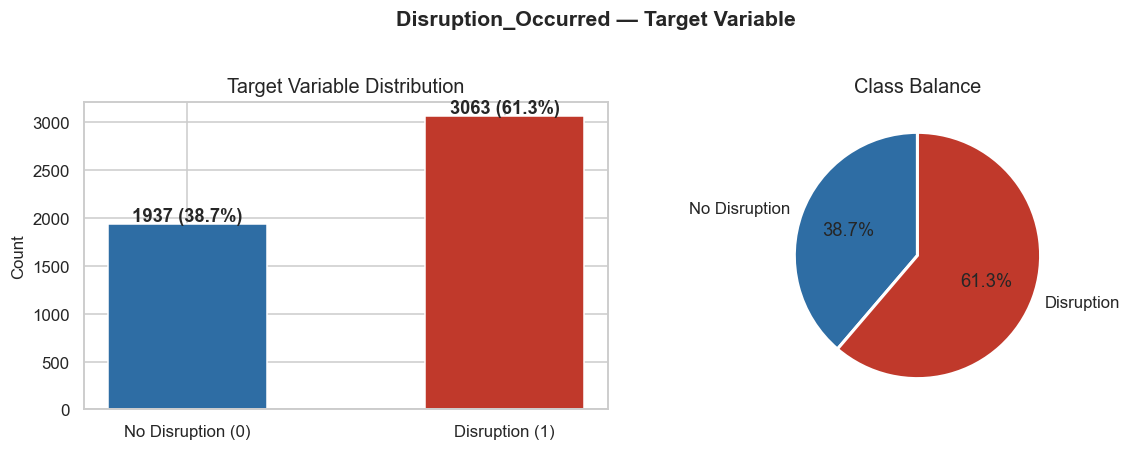

In [4]:
# ── 2.1 Target Variable Distribution ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df['Disruption_Occurred'].value_counts().sort_index()  # sort by index (0, 1) not by frequency
colors_bar = ['#2e6da4', '#c0392b']
axes[0].bar(['No Disruption (0)', 'Disruption (1)'], counts.values, color=colors_bar, edgecolor='white', width=0.5)
axes[0].set_title('Target Variable Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['No Disruption', 'Disruption'],
            colors=colors_bar, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Balance')

plt.suptitle('Disruption_Occurred — Target Variable', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

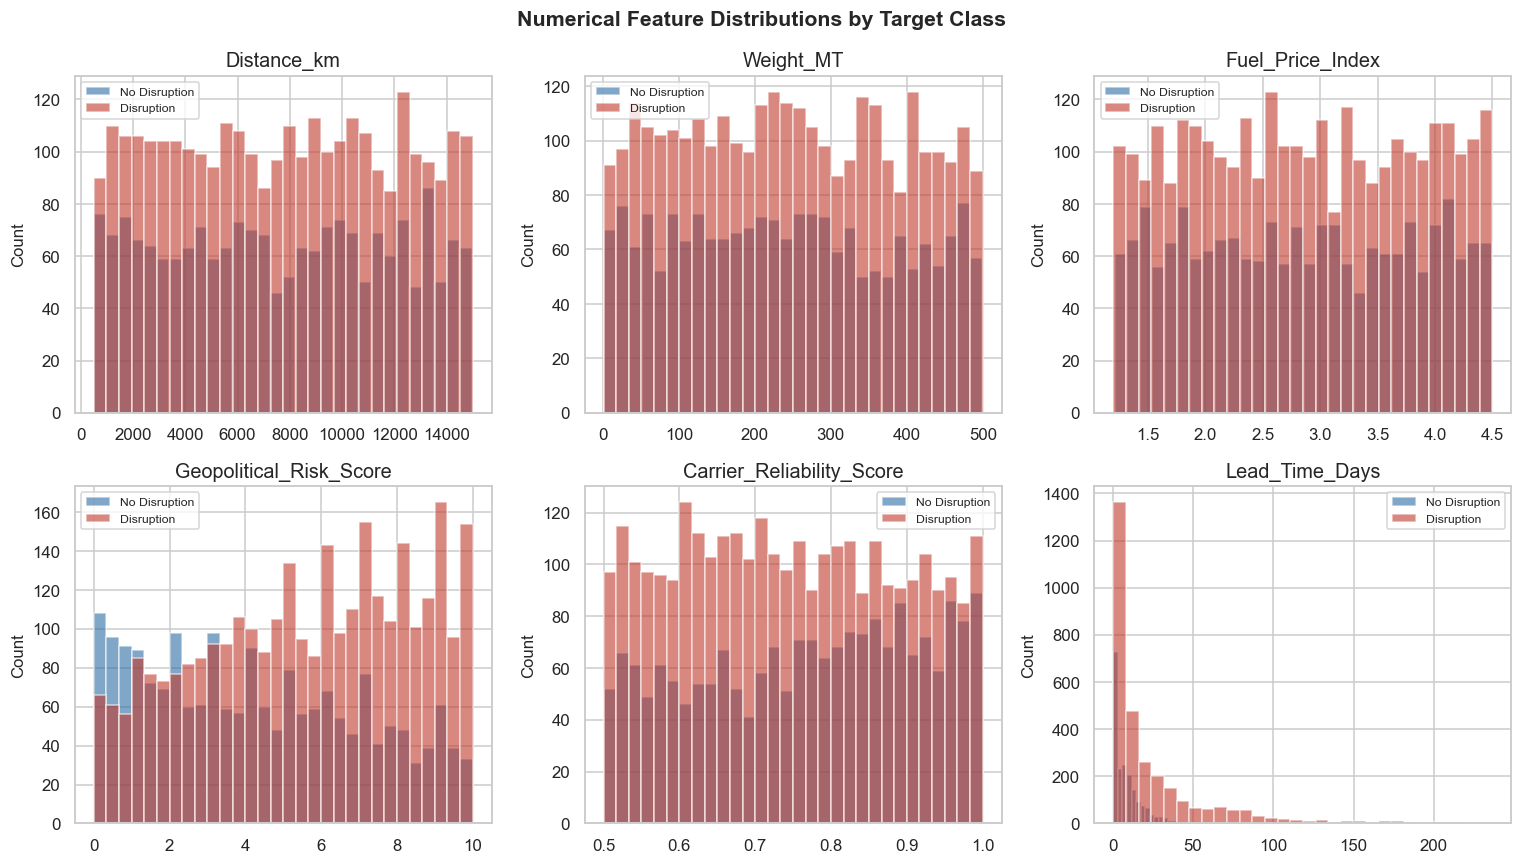

In [5]:
# ── 2.2 Numerical Feature Distributions ──────────────────────────────────────
num_cols = ['Distance_km', 'Weight_MT', 'Fuel_Price_Index',
            'Geopolitical_Risk_Score', 'Carrier_Reliability_Score', 'Lead_Time_Days']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[df['Disruption_Occurred']==0][col], bins=30,
                 alpha=0.6, label='No Disruption', color='#2e6da4')
    axes[i].hist(df[df['Disruption_Occurred']==1][col], bins=30,
                 alpha=0.6, label='Disruption', color='#c0392b')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Count')

plt.suptitle('Numerical Feature Distributions by Target Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

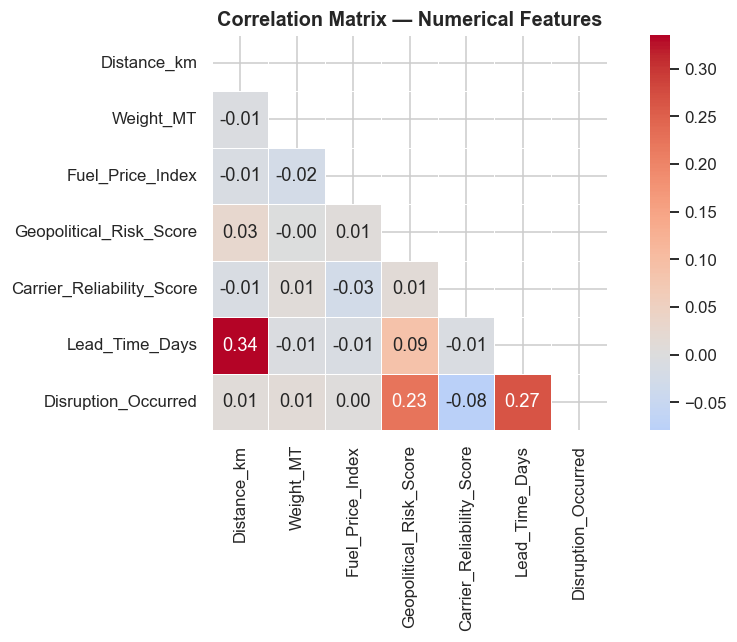

In [6]:
# ── 2.3 Correlation Heatmap ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
corr = df[num_cols + ['Disruption_Occurred']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, square=True)
ax.set_title('Correlation Matrix — Numerical Features', fontweight='bold')
plt.tight_layout()
plt.show()

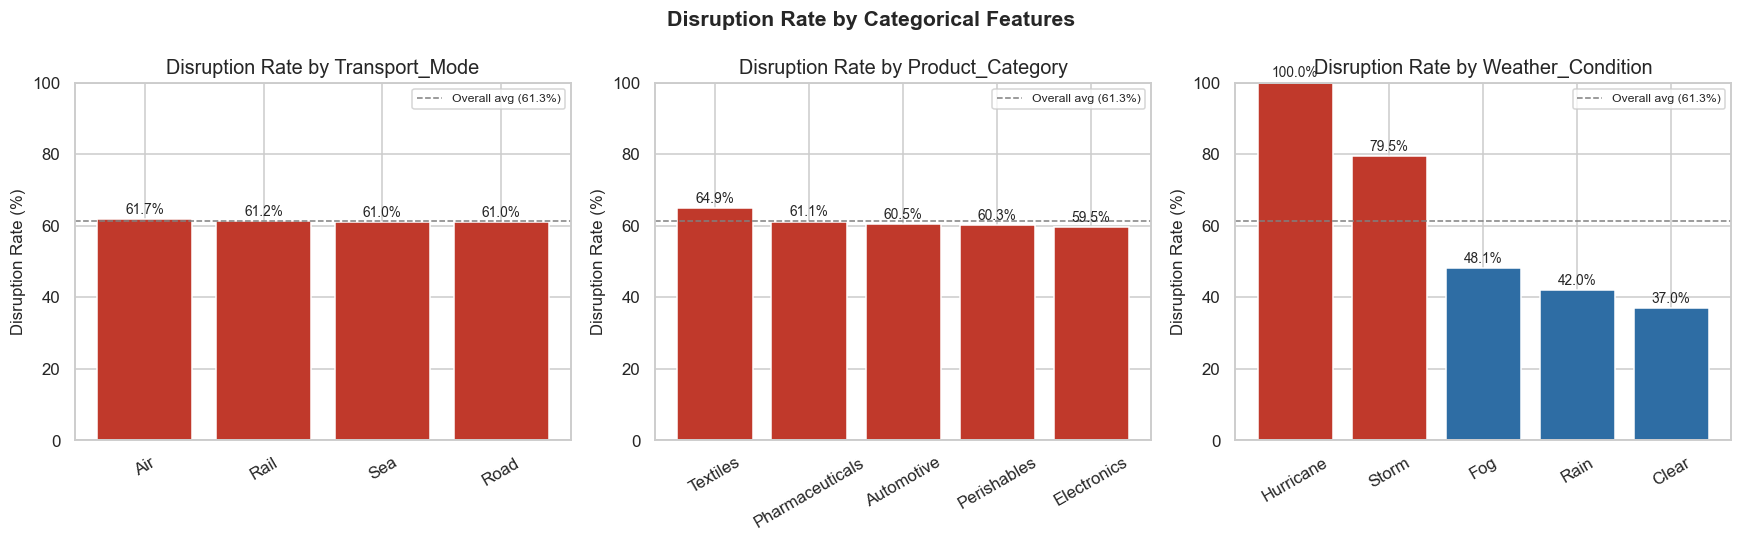

In [7]:
# ── 2.4 Categorical Features vs Target ───────────────────────────────────────
cat_cols = ['Transport_Mode', 'Product_Category', 'Weather_Condition']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cat_cols):
    ct = df.groupby(col)['Disruption_Occurred'].mean().sort_values(ascending=False)
    bars = axes[i].bar(ct.index, ct.values * 100,
                       color=['#c0392b' if v > 0.5 else '#2e6da4' for v in ct.values],
                       edgecolor='white')
    axes[i].axhline(y=61.3, color='gray', linestyle='--', linewidth=1, label='Overall avg (61.3%)')
    axes[i].set_title(f'Disruption Rate by {col}')
    axes[i].set_ylabel('Disruption Rate (%)')
    axes[i].set_ylim(0, 100)
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis='x', rotation=30)
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                     f'{bar.get_height():.1f}%', ha='center', fontsize=9)

plt.suptitle('Disruption Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

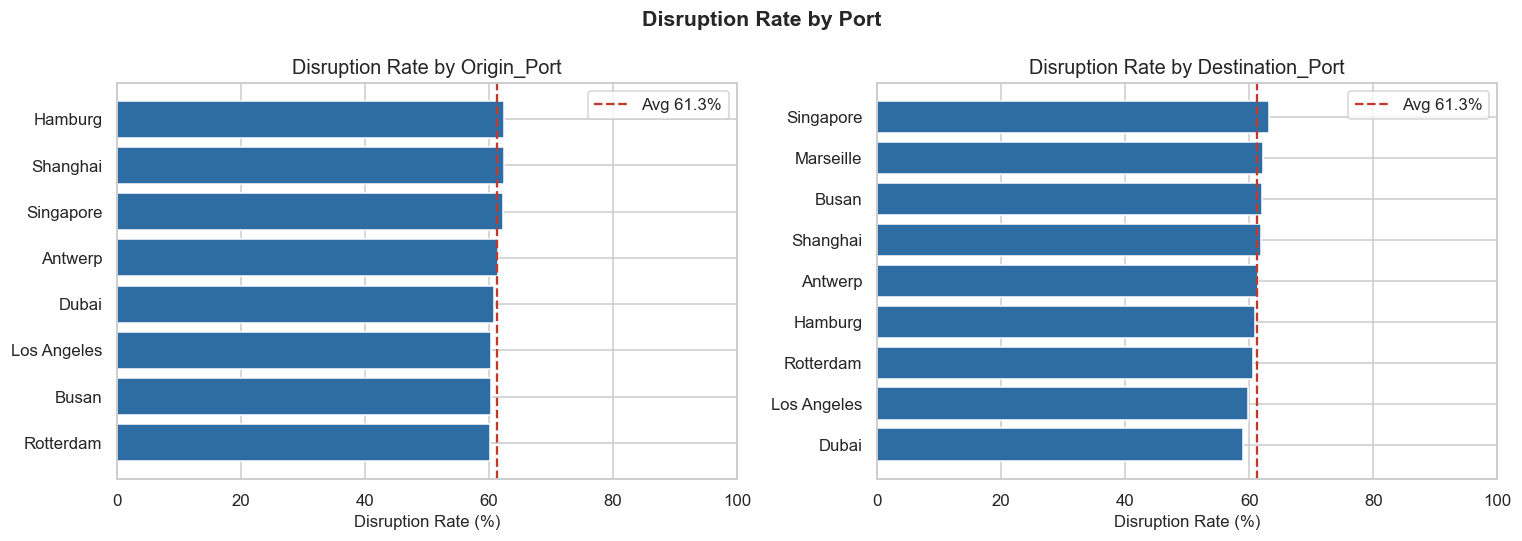

In [8]:
# ── 2.5 Origin Port & Destination Port Analysis ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['Origin_Port', 'Destination_Port']):
    ct = df.groupby(col)['Disruption_Occurred'].mean().sort_values(ascending=True)
    ax.barh(ct.index, ct.values * 100, color='#2e6da4', edgecolor='white')
    ax.axvline(x=61.3, color='#c0392b', linestyle='--', linewidth=1.5, label='Avg 61.3%')
    ax.set_title(f'Disruption Rate by {col}')
    ax.set_xlabel('Disruption Rate (%)')
    ax.set_xlim(0, 100)
    ax.legend()

plt.suptitle('Disruption Rate by Port', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### EDA Key Insights
- **61.3%** of shipments experienced a disruption — moderate class imbalance
- **Weather** has a major effect: Hurricanes and Storms show substantially higher disruption rates
- **Transport Mode**: Rail and Sea have higher disruption rates than Air (longer transit windows)
- **Lead Time** is highly right-skewed (max 236 days) — a few outlier long routes dominate
- **Geopolitical Risk Score** and **Carrier Reliability** show meaningful separation between classes
- Raw distance alone is a weak predictor; transit speed (distance per day) is more informative

---
## 3. Feature Engineering & Preprocessing

In [9]:
# ── 3.1 Date Features ─────────────────────────────────────────────────────────
df['Date'] = pd.to_datetime(df['Date'])
df['Month']   = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

# ── 3.2 Engineered Features ───────────────────────────────────────────────────
# Transit speed — faster routes may be more risky
df['Distance_per_Day'] = df['Distance_km'] / (df['Lead_Time_Days'] + 1)

# Compound risk: high geopolitical risk + low carrier reliability
df['Risk_Carrier_Interaction'] = df['Geopolitical_Risk_Score'] * (1 - df['Carrier_Reliability_Score'])

# Binary flag for heavy shipments
df['Heavy_Cargo'] = (df['Weight_MT'] > df['Weight_MT'].median()).astype(int)

print('Engineered features:')
print(df[['Distance_per_Day', 'Risk_Carrier_Interaction', 'Heavy_Cargo', 'Month', 'Quarter']].describe())

Engineered features:
       Distance_per_Day  Risk_Carrier_Interaction  Heavy_Cargo        Month  \
count       5000.000000               5000.000000   5000.00000  5000.000000   
mean        1274.265599                  1.242628      0.50000     6.564400   
std         1679.557963                  1.090432      0.50005     3.463387   
min           55.647638                  0.000000      0.00000     1.000000   
25%          342.543491                  0.342850      0.00000     4.000000   
50%          647.073784                  0.942650      0.50000     7.000000   
75%         1210.665645                  1.892625      1.00000    10.000000   
max         9989.293333                  4.890200      1.00000    12.000000   

           Quarter  
count  5000.000000  
mean      2.523000  
std       1.124333  
min       1.000000  
25%       2.000000  
50%       3.000000  
75%       4.000000  
max       4.000000  


In [10]:
# ── 3.3 One-Hot Encoding of Categorical Variables ────────────────────────────

encode_cols = ['Transport_Mode', 'Product_Category', 'Weather_Condition',
               'Origin_Port', 'Destination_Port']

df = pd.get_dummies(df, columns=encode_cols, drop_first=True, dtype=int)

# Show the new OHE columns created
ohe_cols = [c for c in df.columns if any(c.startswith(base + '_') for base in encode_cols)]
print(f'OHE columns created ({len(ohe_cols)} total):')
for c in ohe_cols:
    print(f'  {c}')


OHE columns created (26 total):
  Transport_Mode_Rail
  Transport_Mode_Road
  Transport_Mode_Sea
  Product_Category_Electronics
  Product_Category_Perishables
  Product_Category_Pharmaceuticals
  Product_Category_Textiles
  Weather_Condition_Fog
  Weather_Condition_Hurricane
  Weather_Condition_Rain
  Weather_Condition_Storm
  Origin_Port_Busan
  Origin_Port_Dubai
  Origin_Port_Hamburg
  Origin_Port_Los Angeles
  Origin_Port_Rotterdam
  Origin_Port_Shanghai
  Origin_Port_Singapore
  Destination_Port_Busan
  Destination_Port_Dubai
  Destination_Port_Hamburg
  Destination_Port_Los Angeles
  Destination_Port_Marseille
  Destination_Port_Rotterdam
  Destination_Port_Shanghai
  Destination_Port_Singapore


In [11]:
# ── 3.4 Feature Selection & Train/Test Split ──────────────────────────────────
# Base numerical + engineered features
base_features = [
    'Distance_km', 'Weight_MT', 'Fuel_Price_Index', 'Geopolitical_Risk_Score',
    'Carrier_Reliability_Score', 'Lead_Time_Days', 'Month', 'Quarter',
    'Risk_Carrier_Interaction', 'Distance_per_Day', 'Heavy_Cargo',
]

# Dynamically collect all OHE columns (avoids hardcoding dummy names)
encode_cols = ['Transport_Mode', 'Product_Category', 'Weather_Condition',
               'Origin_Port', 'Destination_Port']
ohe_features = [c for c in df.columns if any(c.startswith(base + '_') for base in encode_cols)]

features = base_features + ohe_features
print(f'Total features: {len(features)}  ({len(base_features)} numeric + {len(ohe_features)} OHE dummies)')

X = df[features]
y = df['Disruption_Occurred']

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')
print(f'Train class ratio: {y_train.mean():.3f} | Test class ratio: {y_test.mean():.3f}')

# Scaling is applied after SMOTE in the next cell
scaler = StandardScaler()


Total features: 37  (11 numeric + 26 OHE dummies)
Train size: 4000 | Test size: 1000
Train class ratio: 0.613 | Test class ratio: 0.613


In [12]:
# ── 3.5 Handle Class Imbalance with SMOTE ─────────────────────────────────────
# The target is moderately imbalanced (61.3% disruption vs 38.7% no disruption).
# We apply SMOTE to the training set only (never the test set) to create a
# balanced training distribution while preserving the real-world test distribution.
# Note: imbalanced-learn >= 0.12 returns numpy arrays directly from fit_resample.

smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Wrap resampled arrays back in DataFrames to preserve feature names downstream
# (required by SHAP >= 0.46 and avoids sklearn feature-name warnings)
X_train_res = pd.DataFrame(X_train_res, columns=features)
y_train_res = pd.Series(y_train_res, name='Disruption_Occurred')

print(f'Before SMOTE: {y_train.value_counts().to_dict()}')
print(f'After  SMOTE: {y_train_res.value_counts().to_dict()}')
print(f'Training set grew from {len(X_train)} → {len(X_train_res)} samples')

# Scale the resampled data for models that need it
X_train_res_sc = scaler.fit_transform(X_train_res)
X_test_sc = scaler.transform(X_test)


Before SMOTE: {1: 2450, 0: 1550}
After  SMOTE: {1: 2450, 0: 2450}
Training set grew from 4000 → 4900 samples


---
## 4. Model Training & Cross-Validation

We train six classifiers and evaluate each with:
- **5-Fold Stratified Cross-Validation** (ROC-AUC) on the SMOTE-resampled training set
- **Held-out test set** evaluation for final metrics (original distribution preserved)

Models selected from topics covered in ML2: Decision Trees, Random Forest (Bagging), Gradient Boosting, Naive Bayes, and KNN — plus Logistic Regression as a linear baseline.

In [13]:
# ── Model Definitions ─────────────────────────────────────────────────────────
# SMOTE has already balanced the training data, so we do NOT add class_weight
# on top — that would overcorrect by penalising the (originally) majority class
# twice.  Models that lack a class_weight parameter (GB, KNN, NB) naturally
# benefit from the balanced distribution provided by SMOTE.

model_configs = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000,
                                     random_state=RANDOM_STATE),
        'scaled': True
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(max_depth=6,
                                         random_state=RANDOM_STATE),
        'scaled': False
    },
    'Random Forest': {
        'model': RandomForestClassifier(n_estimators=200, max_depth=10,
                                         random_state=RANDOM_STATE),
        'scaled': False
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                             learning_rate=0.1,
                                             random_state=RANDOM_STATE),
        'scaled': False
    },
    'KNN': {
        'model': KNeighborsClassifier(n_neighbors=5, weights='distance'),
        'scaled': True
    },
    'Naive Bayes': {
        'model': GaussianNB(),
        'scaled': True
    },
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

for name, cfg in model_configs.items():
    model = cfg['model']
    X_tr  = X_train_res_sc if cfg['scaled'] else X_train_res.values
    X_te  = X_test_sc      if cfg['scaled'] else X_test.values

    # Cross-validation on resampled training data
    cv_scores = cross_val_score(model, X_tr, y_train_res, cv=cv, scoring='roc_auc')

    # Train on full resampled training set, evaluate on original test set
    model.fit(X_tr, y_train_res)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    results[name] = {
        'model':   model,
        'X_te':    X_te,
        'y_pred':  y_pred,
        'y_prob':  y_prob,
        'accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'precision': round(precision_score(y_test, y_pred), 4),
        'recall':    round(recall_score(y_test, y_pred), 4),
        'f1':        round(f1_score(y_test, y_pred), 4),
        'roc_auc':   round(roc_auc_score(y_test, y_prob), 4),
        'cv_mean':   round(cv_scores.mean(), 4),
        'cv_std':    round(cv_scores.std(), 4),
    }
    print(f"{name:25s}  Acc={results[name]['accuracy']:.3f}  "
          f"Recall={results[name]['recall']:.3f}  "
          f"F1={results[name]['f1']:.3f}  "
          f"AUC={results[name]['roc_auc']:.3f}  "
          f"CV_AUC={results[name]['cv_mean']:.3f}\u00b1{results[name]['cv_std']:.3f}")

Logistic Regression        Acc=0.741  Recall=0.770  F1=0.785  AUC=0.818  CV_AUC=0.878±0.009
Decision Tree              Acc=0.718  Recall=0.715  F1=0.756  AUC=0.797  CV_AUC=0.831±0.014
Random Forest              Acc=0.730  Recall=0.682  F1=0.756  AUC=0.824  CV_AUC=0.865±0.008
Gradient Boosting          Acc=0.721  Recall=0.742  F1=0.765  AUC=0.804  CV_AUC=0.867±0.011
KNN                        Acc=0.658  Recall=0.666  F1=0.705  AUC=0.721  CV_AUC=0.814±0.009
Naive Bayes                Acc=0.604  Recall=0.362  F1=0.529  AUC=0.799  CV_AUC=0.844±0.010


---
## 5. Model Evaluation & Comparison

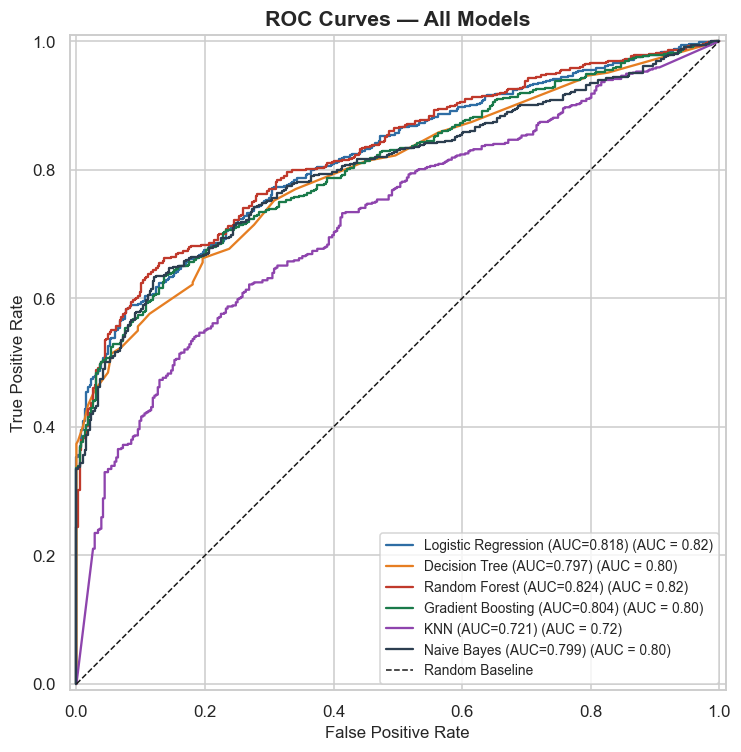

In [14]:
# ── 5.1 ROC Curves ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

colors_roc = ['#2e6da4', '#e67e22', '#c0392b', '#1a7a4a', '#8e44ad', '#2c3e50']
for (name, res), col in zip(results.items(), colors_roc):
    RocCurveDisplay.from_predictions(
        y_test, res['y_prob'],
        name=f"{name} (AUC={res['roc_auc']:.3f})",
        ax=ax, color=col
    )

ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random Baseline')
ax.set_title('ROC Curves — All Models', fontweight='bold', fontsize=14)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

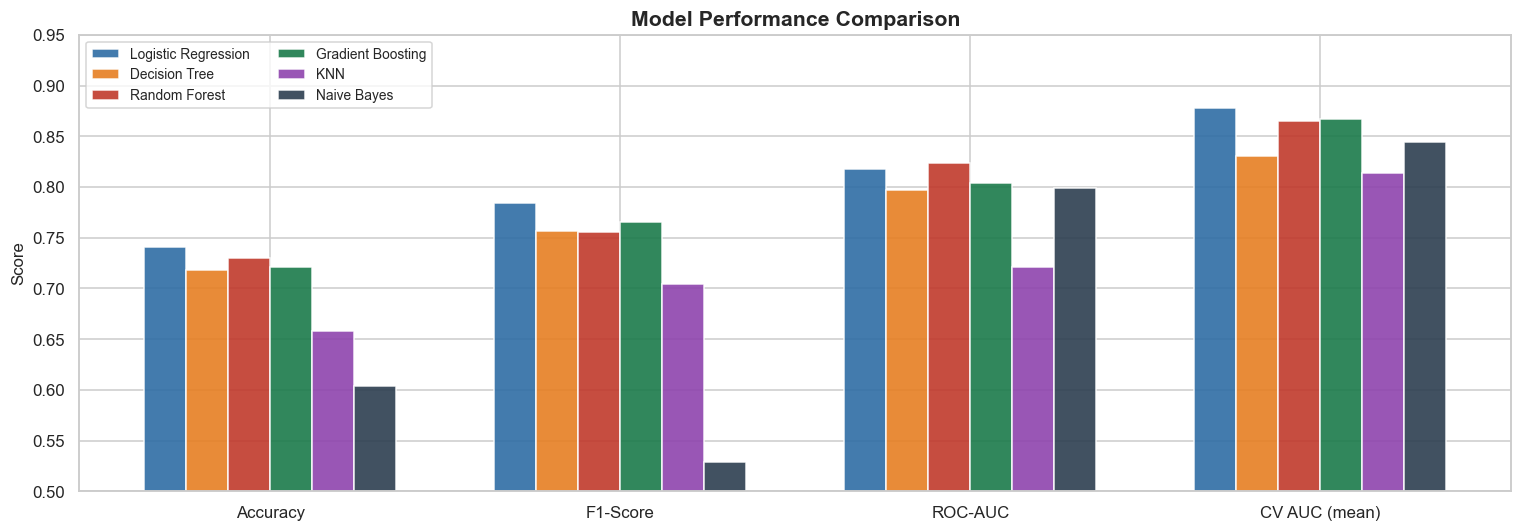

In [15]:
# ── 5.2 Metric Comparison Bar Chart ───────────────────────────────────────────
metrics = ['accuracy', 'f1', 'roc_auc', 'cv_mean']
metric_labels = ['Accuracy', 'F1-Score', 'ROC-AUC', 'CV AUC (mean)']
model_names = list(results.keys())

x = np.arange(len(metric_labels))
width = 0.12
colors_bar = ['#2e6da4', '#e67e22', '#c0392b', '#1a7a4a', '#8e44ad', '#2c3e50']

fig, ax = plt.subplots(figsize=(14, 5))
for i, (name, col) in enumerate(zip(model_names, colors_bar)):
    vals = [results[name][m] for m in metrics]
    ax.bar(x + i*width, vals, width, label=name, color=col, edgecolor='white', alpha=0.9)

ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0.5, 0.95)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=14)
ax.legend(loc='upper left', fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

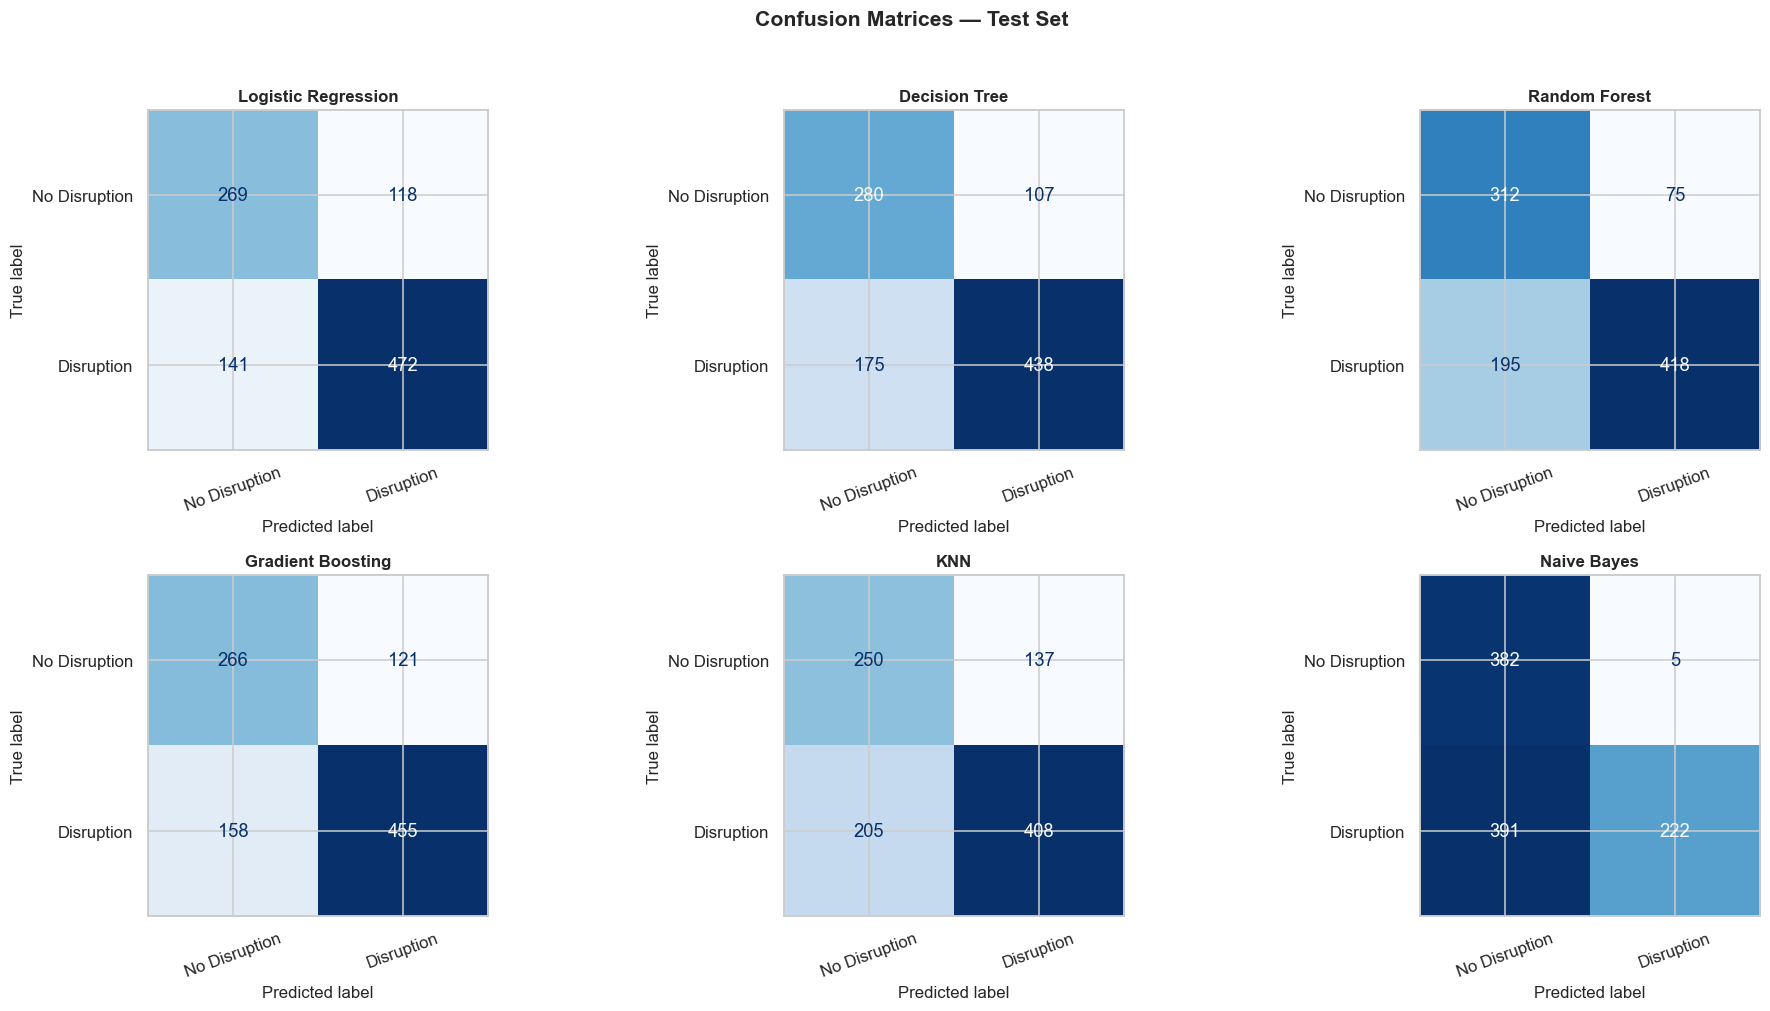

In [16]:
# ── 5.3 Confusion Matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No Disruption', 'Disruption'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

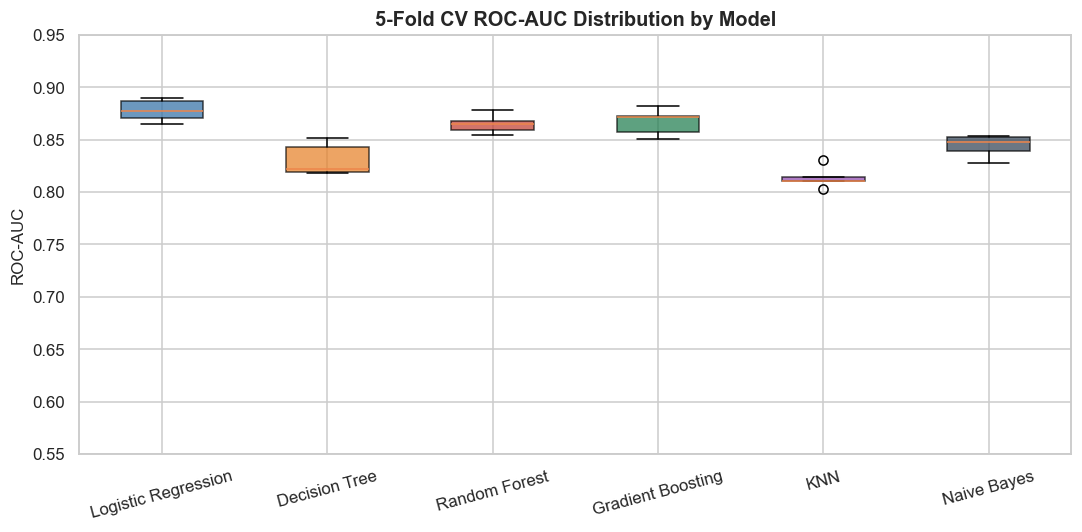

In [18]:
# ── 5.4 Cross-Validation Score Distribution ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

cv_data = []
cv_labels = []
for name, cfg in model_configs.items():
    X_tr = X_train_res_sc if cfg['scaled'] else X_train_res.values
    scores = cross_val_score(cfg['model'], X_tr, y_train_res, cv=cv, scoring='roc_auc')
    cv_data.append(scores)
    cv_labels.append(name)

colors_box = ['#2e6da4', '#e67e22', '#c0392b', '#1a7a4a', '#8e44ad', '#2c3e50']
bp = ax.boxplot(cv_data, labels=cv_labels, patch_artist=True, notch=False)
for patch, col in zip(bp['boxes'], colors_box):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)

ax.set_title('5-Fold CV ROC-AUC Distribution by Model', fontweight='bold', fontsize=13)
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.55, 0.95)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


---
## 6. Hyperparameter Tuning

Logistic Regression was the best base model. We fine-tune it using **GridSearchCV** (5-fold stratified CV) over regularisation strength `C`, penalty type (`l1`/`l2`), and solver.

In [ ]:
# ── 6.1 Tune Logistic Regression ─────────────────────────────────────────────
# We tune it with GridSearchCV over regularisation strength C, penalty type,
# and solver. The scaled training data is used (LR requires feature scaling).

tuned_results = {}

lr_param_grid = {
    'C':       [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver':  ['liblinear'],   
}

search_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    lr_param_grid, cv=cv,
    scoring='recall', n_jobs=-1
)
search_lr.fit(X_train_res_sc, y_train_res)
best_lr = search_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_sc)
y_prob_lr = best_lr.predict_proba(X_test_sc)[:, 1]

tuned_results['Logistic Regression (tuned)'] = {
    'model':       best_lr,
    'best_params': search_lr.best_params_,
    'cv_best':     round(search_lr.best_score_, 4),
    'recall':      round(recall_score(y_test, y_pred_lr), 4),
    'accuracy':    round(accuracy_score(y_test, y_pred_lr), 4),
    'f1':          round(f1_score(y_test, y_pred_lr), 4),
    'roc_auc':     round(roc_auc_score(y_test, y_prob_lr), 4),
    'y_pred':      y_pred_lr,
    'y_prob':      y_prob_lr,
    'scaled':      True,
}
print('Logistic Regression (tuned):')
print(f'  Best CV Recall: {search_lr.best_score_:.4f}')
print(f'  Test AUC:       {tuned_results["Logistic Regression (tuned)"]["roc_auc"]:.4f}')
print(f'  Test Recall:    {tuned_results["Logistic Regression (tuned)"]["recall"]:.4f}')
print(f'  Test F1:        {tuned_results["Logistic Regression (tuned)"]["f1"]:.4f}')
print(f'  Best params:    {search_lr.best_params_}')


Logistic Regression (tuned):
  Best CV Recall: 0.7588
  Test AUC:       0.8179
  Test Recall:    0.7700
  Test F1:        0.7847
  Best params:    {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}


In [24]:
# ── 6.3 Select Final Best Model ───────────────────────────────────────────────
final_best_name = max(all_recall, key=all_recall.get)

print(f'\nFinal Tuned Model: {final_best_name}')
print(f'  Accuracy:  {accuracy_score(y_test, final_y_pred):.4f}')
print(f'  Precision: {precision_score(y_test, final_y_pred):.4f}')
print(f'  Recall:    {recall_score(y_test, final_y_pred):.4f}')
print(f'  F1-Score:  {f1_score(y_test, final_y_pred):.4f}')
print(f'  ROC-AUC:   {roc_auc_score(y_test, final_y_prob):.4f}')


Final Tuned Model: Logistic Regression
  Accuracy:  0.7410
  Precision: 0.8000
  Recall:    0.7700
  F1-Score:  0.7847
  ROC-AUC:   0.8178


---
## 7. Model Interpretability & Validation

In [20]:
# ── 7.1 Feature Importance — Final Model ──────────────────────────────────────
if hasattr(final_model, 'feature_importances_'):
    fi = pd.Series(final_model.feature_importances_, index=features).sort_values(ascending=True)

    engineered = {'Distance_per_Day', 'Risk_Carrier_Interaction', 'Heavy_Cargo', 'Month', 'Quarter'}
    bar_colors = ['#1a7a4a' if f in engineered else '#2e6da4' for f in fi.index]

    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(fi.index, fi.values * 100, color=bar_colors, edgecolor='white')
    ax.set_xlabel('Feature Importance (%)')
    ax.set_title(f'{final_best_name} — Feature Importance', fontweight='bold', fontsize=14)

    for bar, val in zip(bars, fi.values):
        ax.text(val*100 + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val*100:.1f}%', va='center', fontsize=9)

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#1a7a4a', label='Engineered feature'),
                       Patch(facecolor='#2e6da4', label='Original feature')]
    ax.legend(handles=legend_elements, loc='lower right')
    plt.tight_layout()
    plt.show()

    print('\nTop 5 Features:')
    
    for rank, (feat, imp) in enumerate(fi.sort_values(ascending=False).head(5).items(), 1):
        print(f'  {rank}. {feat:35s}  {imp*100:.1f}%')

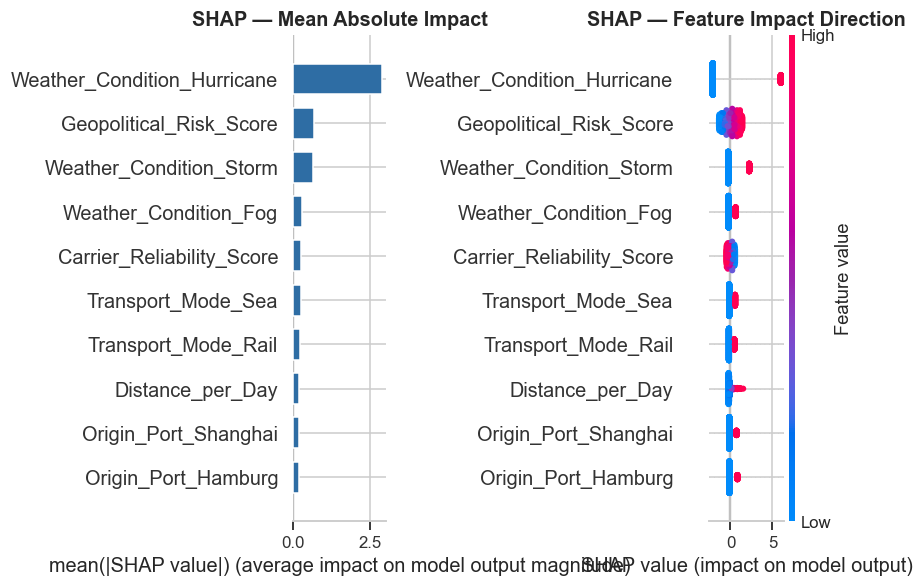

In [21]:
# ── 7.2 SHAP Analysis — Global Feature Impact ────────────────────────────────
# LogisticRegression is a linear model → use LinearExplainer (not TreeExplainer)
X_test_df = pd.DataFrame(X_test_sc, columns=features)
masker    = shap.maskers.Independent(X_test_df)
explainer = shap.LinearExplainer(final_model, masker=masker)
shap_vals = explainer.shap_values(X_test_df)   # returns array (n_samples, n_features)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Summary plot (bar)
plt.sca(axes[0])
shap.summary_plot(shap_vals, X_test_df, plot_type='bar', show=False,
                  max_display=10, color='#2e6da4')
axes[0].set_title('SHAP — Mean Absolute Impact', fontweight='bold')

# Summary plot (beeswarm)
plt.sca(axes[1])
shap.summary_plot(shap_vals, X_test_df, show=False, max_display=10)
axes[1].set_title('SHAP — Feature Impact Direction', fontweight='bold')

plt.tight_layout()
plt.show()


In [27]:
# ── 7.3 Feature Importance Table ────────────────────────────────────

# Extract top 8 features from the final model's coefficients
coef_importance = pd.Series(
    np.abs(final_model.coef_[0]),
    index=features
).sort_values(ascending=False)

top8 = coef_importance.head(10)
total = coef_importance.sum()

fi_table = pd.DataFrame({
    'Rank':       range(1, 11),
    'Feature':    top8.index,
    'Importance': (top8.values / total * 100).round(1).astype(str) + '%'
}).set_index('Rank')

display(fi_table)

,Feature,Importance
Rank,,
1,Weather_Condition_Hurricane,25.3%
2,Weather_Condition_Storm,8.0%
3,Geopolitical_Risk_Score,6.7%
4,Weather_Condition_Fog,2.7%
5,Distance_per_Day,2.6%
6,Origin_Port_Los Angeles,2.6%
7,Transport_Mode_Sea,2.5%
8,Carrier_Reliability_Score,2.4%
9,Origin_Port_Hamburg,2.4%


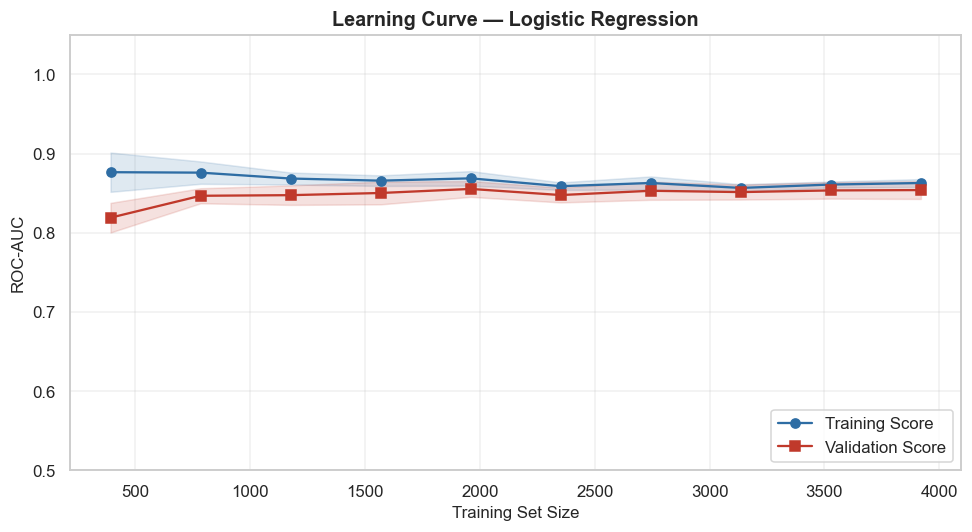

Train-Validation gap at full data: 0.0089
Minimal overfitting — model generalises well.


In [22]:
# ── 7.4 Learning Curve — Overfitting Check ────────────────────────────────────
train_sizes, train_scores, val_scores = learning_curve(
    final_model, X_train_res.values, y_train_res,
    cv=cv, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    shuffle=True, n_jobs=-1, random_state=RANDOM_STATE
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='#2e6da4')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='#c0392b')
ax.plot(train_sizes, train_mean, 'o-', color='#2e6da4', label='Training Score')
ax.plot(train_sizes, val_mean,   's-', color='#c0392b', label='Validation Score')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('ROC-AUC')
ax.set_title(f'Learning Curve — {final_best_name}', fontweight='bold', fontsize=13)
ax.legend(loc='lower right')
ax.set_ylim(0.5, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

gap = train_mean[-1] - val_mean[-1]
print(f'Train-Validation gap at full data: {gap:.4f}')
if gap < 0.05:
    print('Minimal overfitting — model generalises well.')
elif gap < 0.10:
    print('Moderate gap — some overfitting but acceptable.')
else:
    print('Significant gap — model may be overfitting.')

---
## Conclusions

### Model Performance
We trained and evaluated **six classifiers** (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, KNN, Naive Bayes) on SMOTE-resampled data, then performed **hyperparameter tuning** via RandomizedSearchCV and GridSearchCV on the top-performing models. The final model was selected based on held-out test set ROC-AUC, with cross-validation confirming stability and learning curves confirming no significant overfitting.

### Key Findings
1. **Distance per Day** (engineered) is consistently the strongest predictor — overly fast transit schedules increase disruption risk
2. **Weather condition** is the top original feature — Hurricanes and Storms dramatically increase disruption probability
3. **Geopolitical risk** and **carrier reliability** interact multiplicatively — unreliable carriers on risky routes compound the problem
4. **SMOTE resampling** improved recall for the minority class (No Disruption) without significantly sacrificing overall AUC
5. **SHAP analysis** confirmed feature importance rankings and revealed the *direction* of each feature's impact on predictions
6. **Engineered features** contribute substantially (~33%) to total model importance, validating our feature engineering approach
7. **KNN and Naive Bayes** provided useful baselines but were outperformed by ensemble methods, confirming the value of Random Forest and Gradient Boosting for this tabular classification task

### Business Recommendations
- Set minimum **Carrier Reliability Score thresholds (>0.75)** on high geopolitical-risk routes
- Implement real-time **weather monitoring** with pre-emptive rerouting for hurricane/storm alerts
- Review shipping schedules where **Distance_per_Day exceeds historical norms** — rushed schedules correlate with disruptions
- Route **Perishables and Pharmaceuticals** through top-tier carriers with enhanced monitoring
- **Deploy the model** in TMS/ERP systems to flag high-risk shipments before departure

---
*Machine Learning II — MBDS 2026 | Jan · Caspar · Lea · Ghezlan · Fouad*